In [13]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt

In [14]:
points = []
for i in range(1000):
    points_temp = np.random.random_integers(0,1000,(1,100))
    points.append(points_temp)
points = np.array(points).squeeze()

C:\Users\colin\AppData\Local\Temp\ipykernel_14520\334758390.py:3: DeprecationWarning: This function is deprecated. Please call randint(0, 1000 + 1) instead
  points_temp = np.random.random_integers(0,1000,(1,100))


In [15]:
points

array([[ 95, 450, 773, ..., 252, 238, 822],
       [367, 435,  42, ..., 799, 653, 264],
       [668, 585, 679, ...,  73, 646, 340],
       ...,
       [334,  73, 630, ..., 478, 793, 400],
       [ 68, 848, 683, ..., 369, 528, 362],
       [695, 332, 107, ..., 580, 352, 387]],
      shape=(1000, 100), dtype=int32)

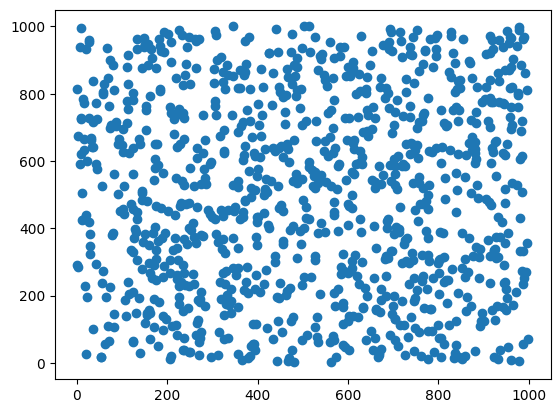

In [16]:
plt.scatter(points[:,0], points[:,1])

In [17]:
def compute_distances(points, num_dims):
    """
    Compute min and max Euclidean distances between all points using the first num_dims dimensions.
    
    Args:
        points: numpy array of shape (n_samples, n_features)
        num_dims: number of dimensions to use for distance calculation
    
    Returns:
        dict with 'min', 'max', and 'avg' keys
    """
    # Extract only the dimensions we need
    subset = points[:, :num_dims]
    
    # Calculate pairwise distances between all points
    from scipy.spatial.distance import pdist
    distances = pdist(subset)
    
    return {
        'min': np.min(distances),
        'max': np.max(distances),
    }

In [18]:
pairwiseDist = []
for i in range(points.shape[1]):
    pairwiseDist.append(compute_distances(points, i+1))

C:\Users\colin\AppData\Local\Temp\ipykernel_14520\454221598.py:1: RuntimeWarning: divide by zero encountered in scalar divide
  maxOvermins = [d['max']/d['min'] for d in pairwiseDist]


Text(0, -0.2, 'As the number of dimensions increases, the pairwise distances go towards 1\nThis means the points are equidistant, creating issues for clustering algorithms\ntraining a model approaches impossible in cases of large dimensionality')

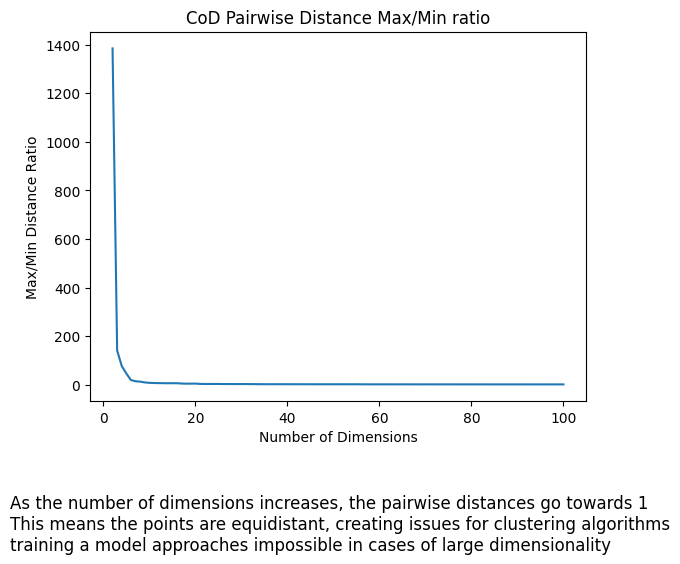

In [19]:
maxOvermins = [d['max']/d['min'] for d in pairwiseDist]
dims = []
for i in range(len(avgs)):
    dims.append(i+1)
#plt.scatter(dims,avgs)
plt.plot(dims,maxOvermins)
plt.xlabel('Number of Dimensions')
plt.ylabel('Max/Min Distance Ratio')
plt.title('CoD Pairwise Distance Max/Min ratio')
str = "As the number of dimensions increases, the pairwise distances go towards 1"
str2 = "This means the points are equidistant, creating issues for clustering algorithms"
str3 = "training a model approaches impossible in cases of large dimensionality"
plt.figtext( 0, -0.2 ,str + "\n" + str2 + "\n" + str3, fontsize=12)
